### Data description

Data comes from Jet Propulsion Laboratory Small-Body Database Query: https://ssd.jpl.nasa.gov/tools/sbdb_query.html

Dataset has 30 columns:
- diameter - diameter of the asteroid [target]
- full_name - Object full name
- a - semi-major axis
- e - eccentricity
- i - inclination with respect to x-y ecliptic plane(deg)
- om - longitude of the ascending node
- w - argument of perihelion
- q - perihelion distance(au)
- ad - aphelion distance(au)
- per_y - orbital periond(years)
- data_arc - data arc span(d)
- condition_code - orbit condition code
- n_obs_used - number of observation used
- H - absolute magnitude parameter
- neo - Near Earth Object
- pha - Physically Hazardous Asteroid
- extent - Object bi/tri axial ellipsoid dimensions(km)
- albedo - geometric albedo
- rot_per - rotation period(h)
- GM - standard gravitational parameter, Product of mass and gravitational constant
- BV - Color index B-V magnitude difference
- UB - Color index U-B magnitude difference
- IR - Color index I-R magnitude difference
- spec_B - Spectral taxonomic type(SMASSII)
- spec_T - Spectral taxonomic type(Tholen)
- G - magnitude slope parameter
- moid - Earth Minimum orbit Intersection Distance(au)
- class - asteroid orbit class
- n - mean motion(deg/d)
- ma - mean anomaly(deg)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

In [7]:
def null_percentage(df: pd.DataFrame, col_name: str) -> float:
    return round(df[col_name].isna().sum() / len(df) * 100, 2)

## Load the data

In [8]:
df = pd.read_csv('data/raw/asteroid_data.csv', low_memory=False)
df = df.copy()
df.T

,0,1,2,3,4,5,6,7,8,9,...,1471190,1471191,1471192,1471193,1471194,1471195,1471196,1471197,1471198,1471199
full_name,1 Ceres (A801 AA),2 Pallas (A802 FA),3 Juno (A804 RA),4 Vesta (A807 FA),5 Astraea (A845 XA),6 Hebe (A847 NA),7 Iris (A847 PA),8 Flora (A847 UA),9 Metis (A848 HA),10 Hygiea (A849 GA),...,(2025 UM6),(2025 UN6),(2025 UO6),(2025 UP6),(2025 UR6),(4847 P-L),(6331 P-L),(6344 P-L),(2015 BA620),(2015 BB620)
a,2.766,2.77,2.671,2.362,2.577,2.425,2.387,2.201,2.387,3.148,...,1.108,1.542,3.035,1.38,1.084,2.425,2.336,2.821,2.359,2.717
e,0.0796,0.2306,0.2558,0.0902,0.1875,0.2022,0.2302,0.1563,0.1226,0.1082,...,0.2196,0.4172,0.6044,0.3544,0.3062,0.2498,0.2827,0.6617,0.1297,0.1492
i,10.59,34.93,12.99,7.14,5.36,14.74,5.52,5.89,5.58,3.83,...,9.71,31.71,14.7,10.56,47.06,5.73,8.08,4.68,11.45,17.5
om,80.25,172.89,169.82,103.7,141.45,138.61,259.49,110.84,68.87,283.12,...,206.53,209.49,235.84,214.7,33.81,14.96,355.17,182.76,8.32,169.43
w,73.3,310.93,247.88,151.54,359.35,239.7,145.48,285.43,5.9,312.61,...,301.16,94.24,118.32,117.34,111.16,338.14,5.38,235.05,162.8,355.55
q,2.546,2.131,1.988,2.149,2.094,1.935,1.837,1.857,2.094,2.807,...,0.864,0.899,1.201,0.891,0.752,1.819,1.676,0.954,2.053,2.312
ad,2.99,3.41,3.35,2.57,3.06,2.92,2.94,2.55,2.68,3.49,...,1.35,2.19,4.87,1.87,1.42,3.03,3.0,4.69,2.67,3.12
per_y,4.6,4.61,4.37,3.63,4.14,3.78,3.69,3.27,3.69,5.58,...,1.17,1.91,5.29,1.62,1.13,3.78,3.57,4.74,3.62,4.48
data_arc,9520.0,80696.0,80649.0,25743.0,65619.0,64264.0,64432.0,64929.0,64291.0,64360.0,...,7.0,7.0,2.0,1.0,2.0,23388.0,23276.0,22229.0,3562.0,7.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471200 entries, 0 to 1471199
Data columns (total 30 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   full_name       1471200 non-null  object 
 1   a               1471200 non-null  float64
 2   e               1471200 non-null  float64
 3   i               1471200 non-null  float64
 4   om              1471200 non-null  float64
 5   w               1471200 non-null  float64
 6   q               1471200 non-null  float64
 7   ad              1471194 non-null  float64
 8   per_y           1471194 non-null  float64
 9   data_arc        1468709 non-null  float64
 10  condition_code  1471177 non-null  float64
 11  n_obs_used      1471200 non-null  int64  
 12  H               1470623 non-null  float64
 13  diameter        139591 non-null   float64
 14  extent          21 non-null       object 
 15  albedo          138468 non-null   float64
 16  rot_per         34595 non-null    fl

In [10]:
df.shape

(1471200, 30)

## Data analysis

#### Target: diameter

In [11]:
df.diameter.dtype

dtype('float64')

In [12]:
df = df.dropna(subset=['diameter'])

In [13]:
df.shape

(139591, 30)

In [14]:
df.diameter.describe()

count    139591.000000
mean          5.459478
std           9.307287
min           0.002500
25%           2.764000
50%           3.950000
75%           5.732000
max         939.400000
Name: diameter, dtype: float64

In [15]:
df.nsmallest(1000, 'diameter')['diameter']

957103     0.0025
911677     0.0080
912122     0.0080
1149453    0.0080
848114     0.0110
            ...  
211683     1.0540
914930     1.0540
137031     1.0550
365430     1.0550
171685     1.0570
Name: diameter, Length: 1000, dtype: float64

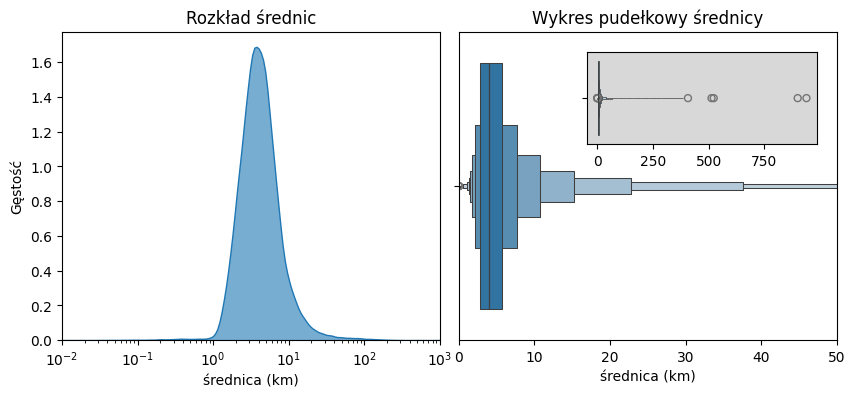

In [16]:
### Visualisation of diameter
fig = plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=0.05)

plt.subplot(121, xlabel='średnica (km)', ylabel='Gęstość', title='Rozkład średnic', xlim=(10**-2, 10**3))
sns.kdeplot(data=df, x='diameter', fill=True, log_scale=True, alpha=0.6)

plt.subplot(122, title='Wykres pudełkowy średnicy', xlim=(0, 50))
sns.boxenplot(data=df, x='diameter')
plt.gca().set(xlabel='średnica (km)')

fig.add_axes([0.65,0.6,0.23,0.23])
zoom_out_ax = sns.boxenplot(data=df, x='diameter', linewidth=.5)
zoom_out_ax.set_facecolor('#D8D8D8')
plt.xlabel('')

plt.savefig('fig/diameter_distribution.pdf')

### Absolute Magnitude (H)

In [17]:
df_tmp = df.copy()

In [18]:
df_tmp.H.describe()

count    139149.000000
mean         15.342753
std           1.436207
min           3.250000
25%          14.590000
50%          15.430000
75%          16.230000
max          29.900000
Name: H, dtype: float64

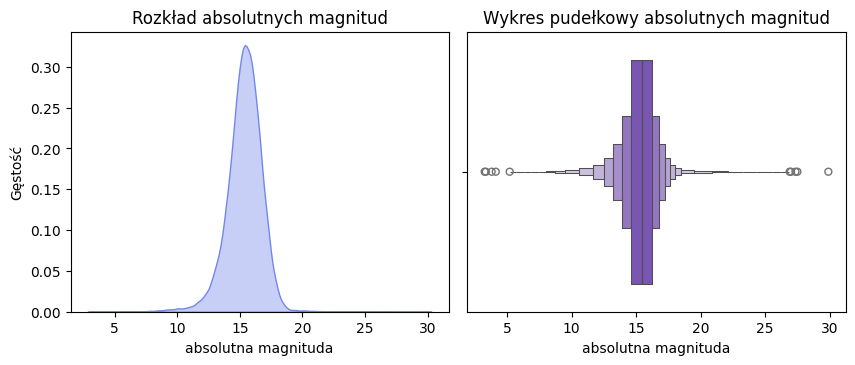

In [19]:
fig = plt.figure(figsize=(10,8))
plt.subplots_adjust(wspace=0.05)

plt.subplot(221, xlabel='absolutna magnituda', ylabel='Gęstość', title='Rozkład absolutnych magnitud')
sns.kdeplot(data=df_tmp, x='H',fill=True, color='#7387EB', alpha=0.4)

plt.subplot(222, title='Wykres pudełkowy absolutnych magnitud')
sns.boxenplot(data=df_tmp, x='H',color='#7647C2')
plt.xlabel('absolutna magnituda')

plt.savefig('fig/magnitude_distribution.pdf')

### Albedo

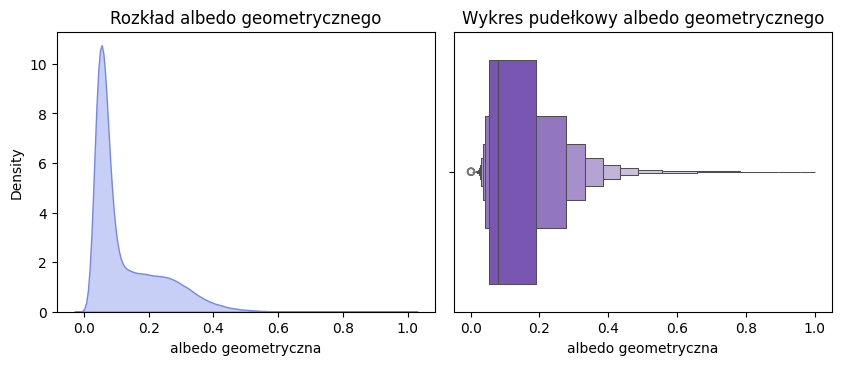

In [20]:
fig = plt.figure(figsize=(10,8))
plt.subplots_adjust(wspace=0.05)

plt.subplot(221, xlabel='albedo geometryczna', title='Rozkład albedo geometrycznego', )
sns.kdeplot(data=df_tmp, x='albedo',fill=True, color='#7387EB', alpha=.4)

plt.subplot(222, title='Wykres pudełkowy albedo geometrycznego', )
sns.boxenplot(data=df_tmp, x='albedo',color='#7647C2')
plt.xlabel('albedo geometryczna')

plt.savefig('fig/albedo_distribution.pdf')

### Diameter, albedo and abolute magnitude relation

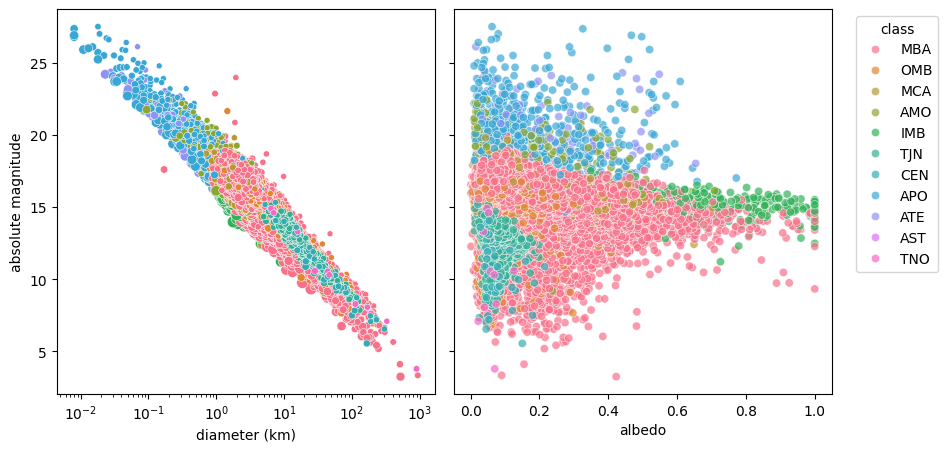

In [21]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
plt.subplots_adjust(wspace=0.05)

ax[0].set(xscale='log', xlabel='diameter (km)', ylabel='absolute magnitude')
sns.scatterplot(df_tmp, x='diameter', y='H', hue='class', 
                size='albedo', ax=ax[0])
ax[0].legend().set_visible(False)

ax[1].set(xlabel='albedo',)
sns.scatterplot(df_tmp, x='albedo', y='H', hue='class', alpha=.7,
                ax=ax[1])
sns.move_legend(ax[1], "upper right", bbox_to_anchor=(1.3, 1.),)

plt.savefig('fig/diameter_albedo_magnitude_relation.jpg')

### Columns with too much missing data
Althought we see interesting columns describing spectral parameters (BV, UB, IR, spec_B, spec_T) as well as physical ones (extent, GM, G) and rotation period (rot_per), they have too much missing values to be of any use for model training. Because of that we drop them.

In [22]:
too_much_na = []
for col in df.columns:

    null_pctg = null_percentage(df, col)

    if null_pctg > 50:
        too_much_na.append((col, null_pctg))

too_much_na

[('extent', np.float64(99.99)),
 ('rot_per', np.float64(85.72)),
 ('GM', np.float64(99.99)),
 ('BV', np.float64(99.28)),
 ('UB', np.float64(99.31)),
 ('IR', np.float64(100.0)),
 ('spec_B', np.float64(98.99)),
 ('spec_T', np.float64(99.31)),
 ('G', np.float64(99.91))]

In [23]:
df = df.drop([c[0] for c in too_much_na], axis=1)

### Non-numeric columns

### Full name
We can safely assume that name of the asteroid doesn't impact it's diameter in any way, so we can drop that column.

In [24]:
df.full_name.isna().sum()

np.int64(0)

In [25]:
df.full_name.head()

0           1 Ceres (A801 AA)
1          2 Pallas (A802 FA)
2            3 Juno (A804 RA)
3           4 Vesta (A807 FA)
4         5 Astraea (A845 XA)
Name: full_name, dtype: object

In [26]:
df = df.drop(['full_name'], axis=1)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139591 entries, 0 to 1234644
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   a               139591 non-null  float64
 1   e               139591 non-null  float64
 2   i               139591 non-null  float64
 3   om              139591 non-null  float64
 4   w               139591 non-null  float64
 5   q               139591 non-null  float64
 6   ad              139591 non-null  float64
 7   per_y           139591 non-null  float64
 8   data_arc        139583 non-null  float64
 9   condition_code  139591 non-null  float64
 10  n_obs_used      139591 non-null  int64  
 11  H               139149 non-null  float64
 12  diameter        139591 non-null  float64
 13  albedo          138466 non-null  float64
 14  ma              139591 non-null  float64
 15  neo             139591 non-null  object 
 16  pha             139591 non-null  object 
 17  n             

### NEO and PHA
NEO (Near Earth Object) and PHA (Potentially Hazardous Asteroid) are boolean indicators whether the asteroids peryhelion is less than 1.3 AU (NEO) and whether its minimum orbit intersection distance with Earth is less than 0.05 AU and its absolute magnitude is 22 or brighter - it means that diameter is approximately larger than 140 meters (PHA).

In [28]:
null_percentage(df, 'neo'), null_percentage(df, 'pha')

(np.float64(0.0), np.float64(0.0))

Not many values are missing so we can fill them with majority in the future.

In [29]:
df_plot = df.copy()
df_plot['pha_plot'] = df['pha'].fillna('Missing')
df_plot['neo_plot'] = df['neo'].fillna('Missing')

In [30]:
# # Create comparison data for PHA and NEO
# categories = ['Y', 'N', 'Missing']
# pha_counts = [df_plot['pha_plot'].value_counts().get(cat, 0) for cat in categories]
# neo_counts = [df_plot['neo_plot'].value_counts().get(cat, 0) for cat in categories]

# # Create grouped bar plot
# x = np.arange(len(categories))
# width = 0.35

# fig, ax = plt.subplots(figsize=(10, 6))
# bars1 = ax.bar(x - width/2, pha_counts, width, label='PHA', alpha=0.8)
# bars2 = ax.bar(x + width/2, neo_counts, width, label='NEO', alpha=0.8)

# # Add labels and formatting
# ax.set_xlabel('Category', fontsize=12)
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Comparison of PHA vs NEO Distribution', fontsize=14, fontweight='bold')
# ax.set_xticks(x)
# ax.set_xticklabels(categories)
# ax.legend()
# ax.set_yscale('log')  # Using log scale due to large differences in counts
# ax.grid(axis='y', alpha=0.3)

# # Add count labels on bars
# for bars in [bars1, bars2]:
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2., height,
#                 f'{int(height):,}',
#                 ha='center', va='bottom', fontsize=9)

# plt.tight_layout()
# plt.show()

### Class

In [31]:
null_percentage(df, 'class')

np.float64(0.0)

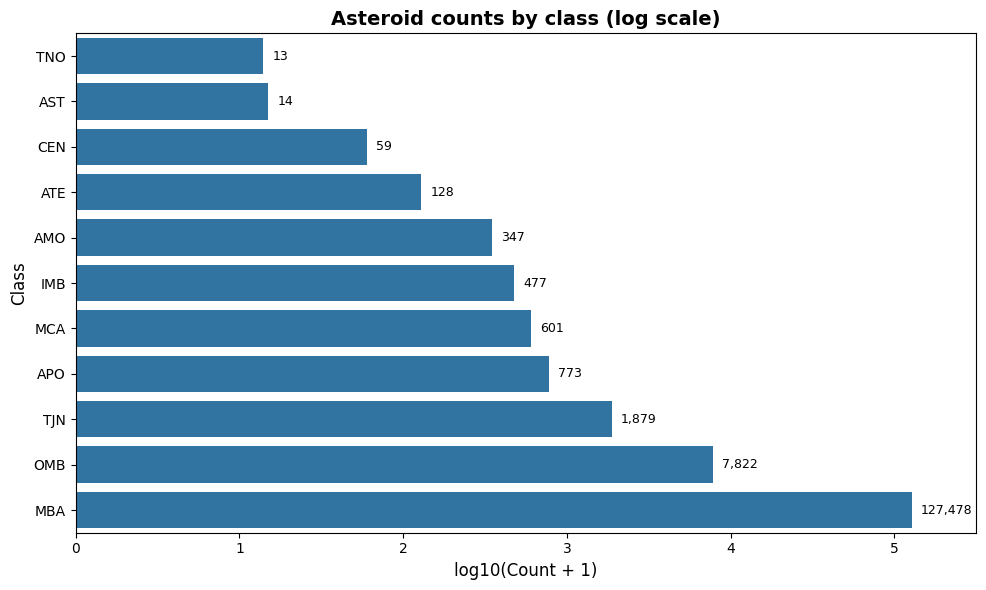

In [32]:
# Plot value counts of df['class'] using log10 of counts
counts = df['class'].value_counts().sort_values(ascending=True)
log_counts = np.log10(counts.values + 1)

fig_class, ax_class = plt.subplots(figsize=(10, max(6, 0.3 * len(counts))))
sns.barplot(x=log_counts, y=counts.index, legend=False, ax=ax_class)

ax_class.set_xlabel('log10(Count + 1)', fontsize=12)
ax_class.set_ylabel('Class', fontsize=12)
ax_class.set_title('Asteroid counts by class (log scale)', fontsize=14, fontweight='bold')

# increase x limit to 5.5
ax_class.set_xlim(0, 5.5)

# Annotate bars with original counts
max_log = ax_class.get_xlim()[1]
for i, v in enumerate(counts.values):
    lv = np.log10(v + 1)
    ax_class.text(lv + max_log * 0.01, i, f'{int(v):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

We can also see the diameter span for each of those classes

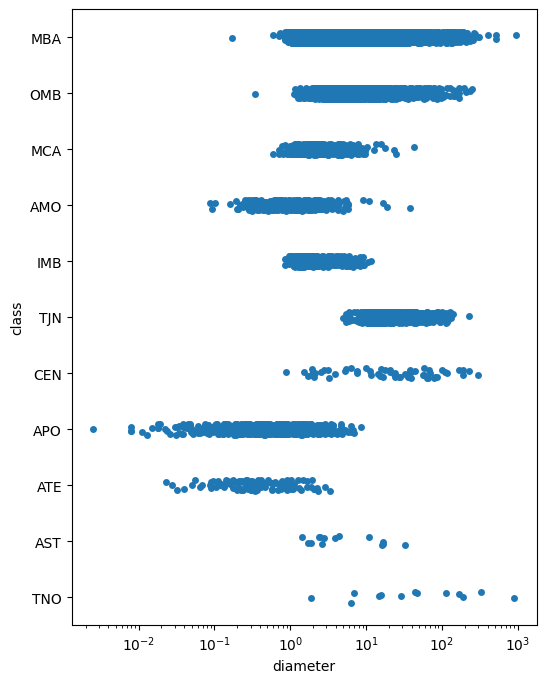

In [33]:
fig = plt.figure(figsize=(6, 8))
sns.stripplot(data=df, x='diameter', y='class')
plt.xscale('log')

### Feature importance

In [34]:
tmp = df.copy()
tmp = tmp.dropna()
tmp = tmp.drop(['class', 'condition_code', 'pha', 'neo'], axis=1)

X_tmp = tmp.drop(['diameter'], axis=1)
y_tmp = tmp['diameter']

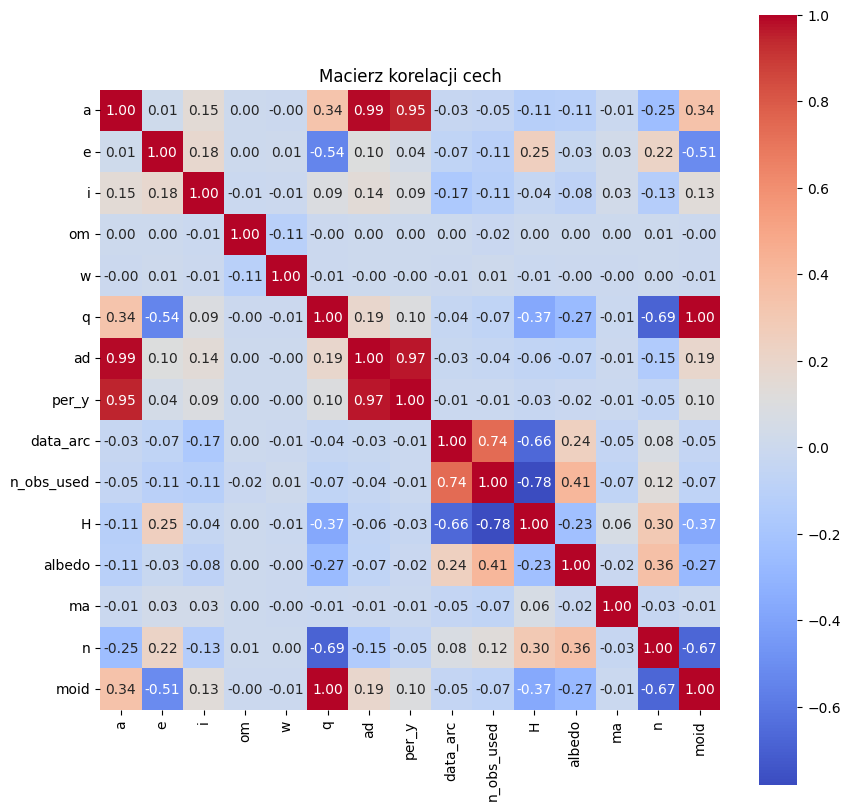

In [35]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    X_tmp.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
plt.title('Macierz korelacji cech')
plt.savefig('fig/correlation_matrix.pdf')

In [36]:
corr_y = X_tmp.corrwith(y_tmp)
corr_y = np.round(corr_y, 2)
corr_y.to_csv('correlation_with_target.csv')
corr_y

a             0.13
e            -0.06
i             0.06
om            0.00
w             0.00
q             0.33
ad            0.08
per_y         0.04
data_arc      0.50
n_obs_used    0.40
H            -0.57
albedo       -0.11
ma           -0.03
n            -0.19
moid          0.33
dtype: float64

In [37]:
mi = mutual_info_regression(X_tmp, y_tmp)

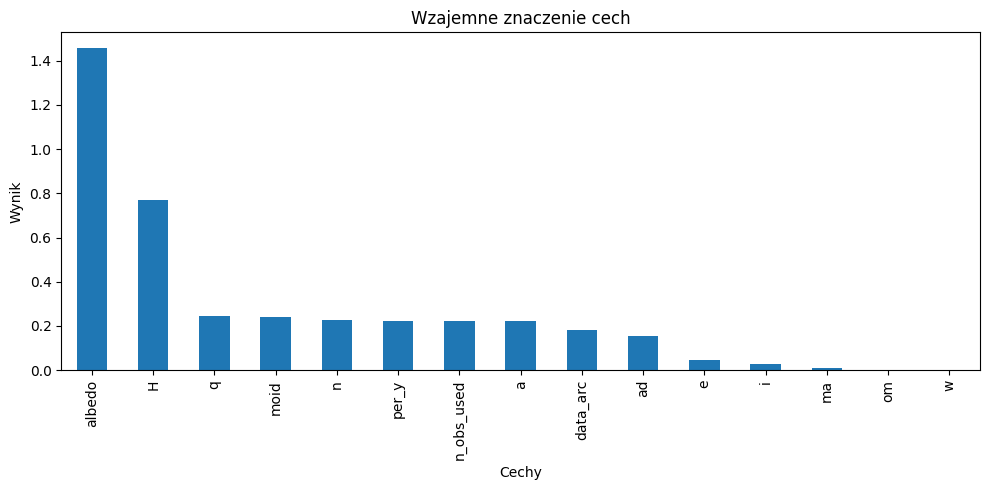

In [38]:
mi_series = pd.Series(mi, index=X_tmp.columns)
mi_series = mi_series.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
mi_series.plot(kind='bar')
plt.title('Wzajemne znaczenie cech')
plt.ylabel('Wynik')
plt.xlabel('Cechy')
plt.tight_layout()
plt.savefig('fig/feature_importance.pdf')

## Data Engineering

In [39]:
# Drop outliers which would bring no information but would decrease model score in MSE and RMSE metrics
top_x_df = df.nlargest(0, 'diameter').index
bottom_x_df = df.nsmallest(0, 'diameter').index

df_filtered = df.drop(top_x_df)
df_filtered = df_filtered.drop(bottom_x_df)

In [40]:
df_filtered.nsmallest(6, 'diameter')['diameter']

957103     0.0025
911677     0.0080
912122     0.0080
1149453    0.0080
848114     0.0110
914031     0.0130
Name: diameter, dtype: float64

In [41]:
df_filtered.nlargest(6, 'diameter')['diameter']

0        939.40
19999    900.00
3        522.77
1        513.00
9        407.12
15788    328.00
Name: diameter, dtype: float64

In [42]:
X = df_filtered.drop(['diameter'], axis=1)
y = df_filtered['diameter']

In [43]:
X.head()

Drop features with high correlation between them.

In [44]:
# X = X.drop(['q', 'ad'], axis=1)

Drop features without correlation to target and other features

In [45]:
# X = X.drop(['om', 'w', 'ma', 'i', 'e'], axis=1)

Drop categorical features for now

In [46]:
X = X.drop(['condition_code', 'class', 'neo', 'pha'], axis=1)

### Fill missing data

In [ ]:
# Model-based imputation with boolean flags for imputed values
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Columns to impute
impute_cols = ['data_arc', 'H', 'albedo']

# Create boolean columns to track imputed values (before imputation)
for col in impute_cols:
    X[f'{col}_imputed'] = X[col].isna()

# Prepare data for imputation (only numeric columns, excluding the boolean flags we just created)
numeric_cols = [col for col in X.select_dtypes(include=[np.number]).columns 
                if not col.endswith('_imputed')]
X_impute = X[numeric_cols].copy()

# Use IterativeImputer with RandomForestRegressor as the estimator
# This uses other features to predict missing values iteratively
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42,
    verbose=0
)

# Fit and transform
X_imputed = imputer.fit_transform(X_impute)
X_imputed_df = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

# Update the original columns with imputed values
for col in impute_cols:
    X[col] = X_imputed_df[col]

# Verify: check how many values were imputed
print("Imputation summary:")
for col in impute_cols:
    imputed_count = X[f'{col}_imputed'].sum()
    print(f"  {col}: {imputed_count} values imputed ({imputed_count/len(X)*100:.2f}%)")

### Classical diameter approximation

### Transform skewed data

In [ ]:
skew_dict = {}
for col in X.columns:
    skew_dict[col] = X[col].skew()
    skew_dict = dict(sorted(skew_dict.items(),key=lambda x: x[1]))
    positive_skew_dict = {k: v for (k, v) in skew_dict.items() if v > 0}
    negative_skew_dict = {k: v for (k, v) in skew_dict.items() if v < 0}

moderately_pos_skewed = [(k, v) for (k, v) in positive_skew_dict.items() if v > 0.5 and v <= 1]
highly_pos_skewed = [(k, v) for (k, v) in positive_skew_dict.items() if v > 1]
moderetely_neg_skewed = [(k, v) for (k, v) in negative_skew_dict.items() if v >- 1 and v <=- 0.5]
highly_neg_skewed = [(k, v) for (k, v) in negative_skew_dict.items() if v < -1]

In [ ]:
print(moderately_pos_skewed)
print(highly_pos_skewed)
print(moderetely_neg_skewed)
print(highly_neg_skewed)

[]
[('i', np.float64(1.6505968814803909)), ('e', np.float64(1.6708465473099172)), ('albedo', np.float64(1.7005079161470034)), ('n_obs_used', np.float64(2.1013092996919793)), ('data_arc', np.float64(2.9827713955126356)), ('n', np.float64(6.932669313063007)), ('q', np.float64(7.028875900286788)), ('moid', np.float64(7.44062042844833)), ('a', np.float64(191.34268272897754)), ('ad', np.float64(212.38154127308144)), ('per_y', np.float64(269.0717717118315))]
[('H', np.float64(-0.5340159609575382))]
[]


In [ ]:
for col, _ in highly_pos_skewed:
    X[col] = np.log1p(X[col])

## Train the models

Using the modular ML framework for easy model comparison and hyperparameter tuning.

In [ ]:
# Import the modular framework
import sys
sys.path.append('src')

from training import ModelTrainer
from evaluation import ModelEvaluator, ModelComparison
from tuning import HyperparameterTuner
from models import (
    LinearRegressionModel, ElasticNetModel, KNeighborsRegressorModel,
    RandomForestRegressorModel, GradientBoostingRegressorModel,
    XGBRegressorModel, LGBMRegressorModel, SVRModel,
    MLPRegressorModel, ClassicalDiameterModel
)

# Initialize trainer (handles data splitting and preprocessing)
trainer = ModelTrainer(test_size=0.2, val_size=0.25, random_state=42, 
                       scale_features=True, use_log_transform=False)
trainer.prepare_data(X, y)

# Get data splits
X_train, y_train = trainer.get_train_data(scaled=True)
X_val, y_val = trainer.get_val_data(scaled=True)
X_test, y_test = trainer.get_test_data(scaled=True)

# Also get unscaled for classical model
X_test_unscaled, y_test_unscaled = trainer.get_test_data(scaled=False)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Val set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (83754, 13), (83754,)
Val set: (27918, 13), (27918,)
Test set: (27919, 13), (27919,)


In [ ]:
# Initialize evaluator and comparison utilities
evaluator = ModelEvaluator(fig_dir='fig')
comparison = ModelComparison(fig_dir='fig')

# Initialize hyperparameter tuner
tuner = HyperparameterTuner(config_path='src/config/model_configs.yaml')

In [ ]:
# Dictionary to store trained models
trained_models = {}

### Classical diameter approximation

In [ ]:
# Classical model doesn't need scaling - use original DataFrame
X_test_df, _ = trainer.get_test_data(scaled=False)
classical_model = ClassicalDiameterModel()
classical_model.fit(X_test_df, y_test_unscaled)
classical_preds = classical_model.predict(X_test_df)

# Evaluate
classical_metrics = evaluator.evaluate(y_test_unscaled, classical_preds, 'Classical')
evaluator.plot_predictions(y_test_unscaled, classical_preds, 'Classical')
comparison.add_result('Classical', classical_metrics)
trained_models['Classical'] = classical_model

print(f"Classical Model - RMSE: {classical_metrics['rmse']:.3f}, MSE: {classical_metrics['mse']:.3f}, MAE: {classical_metrics['mae']:.3f}, R²: {classical_metrics['r2']:.3f}")

ValueError: Missing required columns: ['albedo', 'H']

### Linear Regression

In [ ]:
lr_model = LinearRegressionModel()
trainer.train_model(lr_model)
lr_preds = lr_model.predict(X_test)

lr_metrics = evaluator.evaluate(y_test_unscaled, lr_preds, 'Linear Regression')
evaluator.plot_predictions(y_test_unscaled, lr_preds, 'Linear Regression')
comparison.add_result('Linear Regression', lr_metrics)
trained_models['Linear Regression'] = lr_model

print(f"Linear Regression - RMSE: {lr_metrics['rmse']:.3f}, MSE: {lr_metrics['mse']:.3f}, MAE: {lr_metrics['mae']:.3f}, R²: {lr_metrics['r2']:.3f}")

Linear Regression - RMSE: 8.881, MSE: 78.878, MAE: 1.788, R²: 0.180


### Elastic Net

In [ ]:
elastic_model = ElasticNetModel()
trainer.train_model(elastic_model)
elastic_preds = elastic_model.predict(X_test)

elastic_metrics = evaluator.evaluate(y_test_unscaled, elastic_preds, 'Elastic Net')
evaluator.plot_predictions(y_test_unscaled, elastic_preds, 'Elastic Net')
comparison.add_result('Elastic Net', elastic_metrics)
trained_models['Elastic Net'] = elastic_model

print(f"Elastic Net - RMSE: {elastic_metrics['rmse']:.3f}, MSE: {elastic_metrics['mse']:.3f}, MAE: {elastic_metrics['mae']:.3f}, R²: {elastic_metrics['r2']:.3f}")

Elastic Net - RMSE: 6.849, MSE: 46.912, MAE: 2.609, R²: -0.024


### K-Nearest Neighbors

In [ ]:
knn_model = KNeighborsRegressorModel()
trainer.train_model(knn_model)
knn_preds = knn_model.predict(X_test)

knn_metrics = evaluator.evaluate(y_test_unscaled, knn_preds, 'KNN')
evaluator.plot_predictions(y_test_unscaled, knn_preds, 'KNN')
comparison.add_result('KNN', knn_metrics)
trained_models['KNN'] = knn_model

print(f"KNN - RMSE: {knn_metrics['rmse']:.3f}, MSE: {knn_metrics['mse']:.3f}, MAE: {knn_metrics['mae']:.3f}, R²: {knn_metrics['r2']:.3f}")

KNN - RMSE: 1.720, MSE: 2.959, MAE: 0.591, R²: 0.935


### Random Forest

In [ ]:
rf_model = RandomForestRegressorModel()
trainer.train_model(rf_model)
rf_preds = rf_model.predict(X_test)

rf_metrics = evaluator.evaluate(y_test_unscaled, rf_preds, 'Random Forest')
evaluator.plot_predictions(y_test_unscaled, rf_preds, 'Random Forest')
comparison.add_result('Random Forest', rf_metrics)
trained_models['Random Forest'] = rf_model

print(f"Random Forest - RMSE: {rf_metrics['rmse']:.3f}, MSE: {rf_metrics['mse']:.3f}, MAE: {rf_metrics['mae']:.3f}, R²: {rf_metrics['r2']:.3f}")

Random Forest - RMSE: 0.867, MSE: 0.753, MAE: 0.388, R²: 0.984


### Gradient Boosting

In [ ]:
gb_model = GradientBoostingRegressorModel()
trainer.train_model(gb_model)
gb_preds = gb_model.predict(X_test)

gb_metrics = evaluator.evaluate(y_test_unscaled, gb_preds, 'Gradient Boosting')
evaluator.plot_predictions(y_test_unscaled, gb_preds, 'Gradient Boosting')
comparison.add_result('Gradient Boosting', gb_metrics)
trained_models['Gradient Boosting'] = gb_model

print(f"Gradient Boosting - RMSE: {gb_metrics['rmse']:.3f}, MSE: {gb_metrics['mse']:.3f}, MAE: {gb_metrics['mae']:.3f}, R²: {gb_metrics['r2']:.3f}")

Gradient Boosting - RMSE: 1.025, MSE: 1.050, MAE: 0.429, R²: 0.977


### XGBoost


In [ ]:

xgb_model = XGBRegressorModel()
trainer.train_model(xgb_model)
xgb_preds = xgb_model.predict(X_test)

xgb_metrics = evaluator.evaluate(y_test_unscaled, xgb_preds, 'XGBoost')
evaluator.plot_predictions(y_test_unscaled, xgb_preds, 'XGBoost')
comparison.add_result('XGBoost', xgb_metrics)
trained_models['XGBoost'] = xgb_model

print(f"XGBoost - RMSE: {xgb_metrics['rmse']:.3f}, MSE: {xgb_metrics['mse']:.3f}, MAE: {xgb_metrics['mae']:.3f}, R²: {xgb_metrics['r2']:.3f}")

XGBoost - RMSE: 1.576, MSE: 2.485, MAE: 0.450, R²: 0.946


### LightGBM

In [ ]:
lgbm_model = LGBMRegressorModel()
trainer.train_model(lgbm_model)
lgbm_preds = lgbm_model.predict(X_test)

lgbm_metrics = evaluator.evaluate(y_test_unscaled, lgbm_preds, 'LightGBM')
evaluator.plot_predictions(y_test_unscaled, lgbm_preds, 'LightGBM')
comparison.add_result('LightGBM', lgbm_metrics)
trained_models['LightGBM'] = lgbm_model

print(f"LightGBM - RMSE: {lgbm_metrics['rmse']:.3f}, MSE: {lgbm_metrics['mse']:.3f}, MAE: {lgbm_metrics['mae']:.3f}, R²: {lgbm_metrics['r2']:.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 83694, number of used features: 11
[LightGBM] [Info] Start training from score 1.660837


/home/stpaulo/asteroid-diameter-prediction/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - RMSE: 1.516, MSE: 2.299, MAE: 0.443, R²: 0.950


### Support Vector Regression

In [ ]:
svr_model = SVRModel()
trainer.train_model(svr_model)
svr_preds = svr_model.predict(X_test)

svr_metrics = evaluator.evaluate(y_test_unscaled, svr_preds, 'SVR')
evaluator.plot_predictions(y_test_unscaled, svr_preds, 'SVR')
comparison.add_result('SVR', svr_metrics)
trained_models['SVR'] = svr_model

print(f"SVR - RMSE: {svr_metrics['rmse']:.3f}, MSE: {svr_metrics['mse']:.3f}, MAE: {svr_metrics['mae']:.3f}, R²: {svr_metrics['r2']:.3f}")

SVR - RMSE: 1.432, MSE: 2.052, MAE: 0.431, R²: 0.955


### Multi-Layer Perceptron (MLP)

Epoch 000 | train_loss: 0.5429 | val_loss: 0.0328
Epoch 001 | train_loss: 0.1126 | val_loss: 0.0193
Epoch 002 | train_loss: 0.0855 | val_loss: 0.0147
Epoch 003 | train_loss: 0.0676 | val_loss: 0.0122
Epoch 004 | train_loss: 0.0543 | val_loss: 0.0136
Epoch 005 | train_loss: 0.0447 | val_loss: 0.0132
Epoch 006 | train_loss: 0.0381 | val_loss: 0.0090
Epoch 007 | train_loss: 0.0335 | val_loss: 0.0108
Epoch 008 | train_loss: 0.0305 | val_loss: 0.0124
Epoch 009 | train_loss: 0.0282 | val_loss: 0.0122
Epoch 010 | train_loss: 0.0274 | val_loss: 0.0101
Epoch 011 | train_loss: 0.0265 | val_loss: 0.0121
Epoch 012 | train_loss: 0.0257 | val_loss: 0.0102
Epoch 013 | train_loss: 0.0260 | val_loss: 0.0103
Epoch 014 | train_loss: 0.0256 | val_loss: 0.0109
Epoch 015 | train_loss: 0.0254 | val_loss: 0.0107
Epoch 016 | train_loss: 0.0257 | val_loss: 0.0129
Epoch 017 | train_loss: 0.0250 | val_loss: 0.0125
Epoch 018 | train_loss: 0.0250 | val_loss: 0.0153
Epoch 019 | train_loss: 0.0253 | val_loss: 0.0111


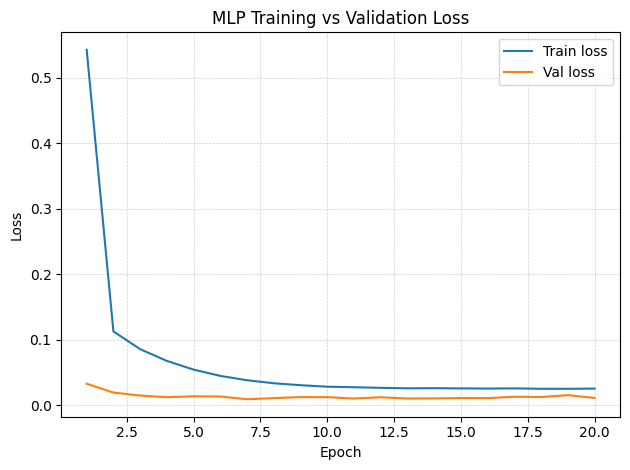

In [ ]:
mlp_model = MLPRegressorModel(hidden_layers=[50, 30, 10], dropout=0.15, 
                                batch_size=128, num_epochs=20, learning_rate=1e-3)
trainer.train_model(mlp_model)
mlp_preds = mlp_model.predict(X_test)

mlp_metrics = evaluator.evaluate(y_test_unscaled, mlp_preds, 'MLP')
evaluator.plot_predictions(y_test_unscaled, mlp_preds, 'MLP')
comparison.add_result('MLP', mlp_metrics)
trained_models['MLP'] = mlp_model

print(f"MLP - RMSE: {mlp_metrics['rmse']:.3f}, MSE: {mlp_metrics['mse']:.3f}, MAE: {mlp_metrics['mae']:.3f}, R²: {mlp_metrics['r2']:.3f}")

# Plot training loss if available
if hasattr(mlp_model, 'train_losses') and mlp_model.train_losses:
    plt.figure()
    epochs = range(1, len(mlp_model.train_losses) + 1)
    plt.plot(epochs, mlp_model.train_losses, label="Train loss")
    if mlp_model.val_losses:
        plt.plot(epochs, mlp_model.val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("MLP Training vs Validation Loss")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.tight_layout()
    plt.savefig('fig/mlp_training_loss.pdf')
    plt.show()

### Model Comparison

In [ ]:
# Generate comparison table
comparison_df = comparison.get_comparison_table()
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))

# Save results
comparison.export_results('model_comparison_results.csv')

# Create comparison visualizations
comparison.plot_comparison()
comparison.plot_metric_comparison('rmse')
comparison.plot_metric_comparison('r2')


=== Model Comparison ===
            model     rmse       mse      mae        r2
    Random Forest 0.867494  0.752546 0.388250  0.983580
Gradient Boosting 1.024784  1.050182 0.429474  0.977086
        Classical 1.224887  1.500347 0.601662  0.967263
              SVR 1.432418  2.051821 0.430755  0.955231
         LightGBM 1.516197  2.298854 0.443140  0.949840
          XGBoost 1.576372  2.484949 0.449749  0.945780
              KNN 1.720220  2.959156 0.591372  0.935433
              MLP 2.077293  4.315146 0.625144  0.905846
Linear Regression 2.433848  5.923616 0.705092  0.870750
      Elastic Net 6.849211 46.911692 2.608570 -0.023584


### Hyperparameter Tuning

##### Linear Regression

In [ ]:
### Hyperparameter Tuning

# Example: Tune Random Forest hyperparameters
print("\n=== Hyperparameter Tuning Example ===")
print("Tuning Random Forest...")

rf_model_tuned = RandomForestRegressorModel()
rf_model_tuned, search_results = tuner.tune_model(
    rf_model_tuned, X_train, y_train, 'random_forest',
    method='optuna', n_iter=5, cv=3, verbose=1, n_jobs=5
)

# Train with best parameters
trainer.train_model(rf_model_tuned)
rf_tuned_preds = rf_model_tuned.predict(X_test)

rf_tuned_metrics = evaluator.evaluate(y_test_unscaled, rf_tuned_preds, 'Random Forest (Tuned)')
evaluator.plot_predictions(y_test_unscaled, rf_tuned_preds, 'Random Forest (Tuned)')
comparison.add_result('Random Forest (Tuned)', rf_tuned_metrics)

print(f"\nBest parameters: {search_results.best_params_}")
print(f"Best CV score: {search_results.best_score_:.4f}")
print(f"Random Forest (Tuned) - RMSE: {rf_tuned_metrics['rmse']:.3f}, MSE: {rf_tuned_metrics['mse']:.3f}, MAE: {rf_tuned_metrics['mae']:.3f}, R²: {rf_tuned_metrics['r2']:.3f}")

[I 2025-12-18 11:33:45,461] A new study created in memory with name: no-name-15d2ec86-01d0-410e-bfba-e4322b1381df



=== Hyperparameter Tuning Example ===
Tuning Random Forest...


[I 2025-12-18 11:34:42,041] Trial 0 finished with value: -0.9655645920122385 and parameters: {'n_estimators': 106, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: -0.9655645920122385.
[I 2025-12-18 11:35:36,451] Trial 1 finished with value: -0.9663421911728932 and parameters: {'n_estimators': 58, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: -0.9655645920122385.
[I 2025-12-18 11:36:33,071] Trial 2 finished with value: -0.967916536479279 and parameters: {'n_estimators': 175, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: -0.9655645920122385.
[I 2025-12-18 11:37:30,056] Trial 3 finished with value: -0.9709923736029863 and parameters: {'n_estimators': 115, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: -0.9655645920122385.
[I 2025-12-18 11:38:35,212] Trial 4 finished with value: -0.9616087983133434 and param

AttributeError: 'Study' object has no attribute 'best_params_'

In [ ]:
search_results.best_params

{'n_estimators': 106,
 'max_depth': 10,
 'min_samples_split': 3,
 'min_samples_leaf': 1}

In [ ]:
# Final comparison with tuned model
final_comparison_df = comparison.get_comparison_table()
print("\n=== Final Model Comparison (including tuned models) ===")
print(final_comparison_df.to_string(index=False))


=== Final Model Comparison (including tuned models) ===
                model     rmse       mse      mae        r2
        Random Forest 1.172763  1.375373 0.408297  0.977548
Random Forest (Tuned) 1.175333  1.381409 0.416156  0.977449
    Gradient Boosting 1.245181  1.550475 0.449682  0.974689
            Classical 1.285541  1.652616 0.612146  0.973022
                  MLP 2.005014  4.020082 0.582439  0.934374
                  SVR 2.022067  4.088755 0.450465  0.933253
                  KNN 2.077703  4.316850 0.613899  0.929529
             LightGBM 2.133987  4.553900 0.468741  0.925660
              XGBoost 2.256464  5.091630 0.481120  0.916881
    Linear Regression 2.933738  8.606820 0.738933  0.859497
          Elastic Net 3.657241 13.375410 0.760552  0.781652
  Elastic Net (Tuned) 7.910144 62.570378 2.732182 -0.021434


In [ ]:
# Note: To tune other models, use:
# model, search_results = tuner.tune_model(model, X_train, y_train, 'model_name', method='randomized')